#### remember taker vs maker strat

we need to pick, size of our trades, entry/exit signal, leverage (borrowing money)

In [7]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import polars as pl
import numpy as np
from datetime import datetime, timedelta
import random

import torch
import torch.nn as nn
import torch.optim as optim
import research

import altair as alt

import binance

In [8]:
import models

model = models.LinearModel(1)

model.load_state_dict(torch.load('1d_lag3_model.pth', weights_only=True))
model.eval()

LinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

### Model Params

In [9]:
research.print_model_params(model)

linear.weight:
[[-0.02642301]]
linear.bias:
[-0.0001091]


### Mean Reversion

In [10]:
series = [-0.014, 0.011399, -0.012212, 0.01997, -0.01442, 0.01227]
mu = np.mean(series)
mean_reversion_df = pl.DataFrame({'log_return': series, 'mean': mu})
mean_reversion_df

log_return,mean
f64,f64
-0.014,0.000501
0.011399,0.000501
-0.012212,0.000501
0.01997,0.000501
-0.01442,0.000501
0.01227,0.000501


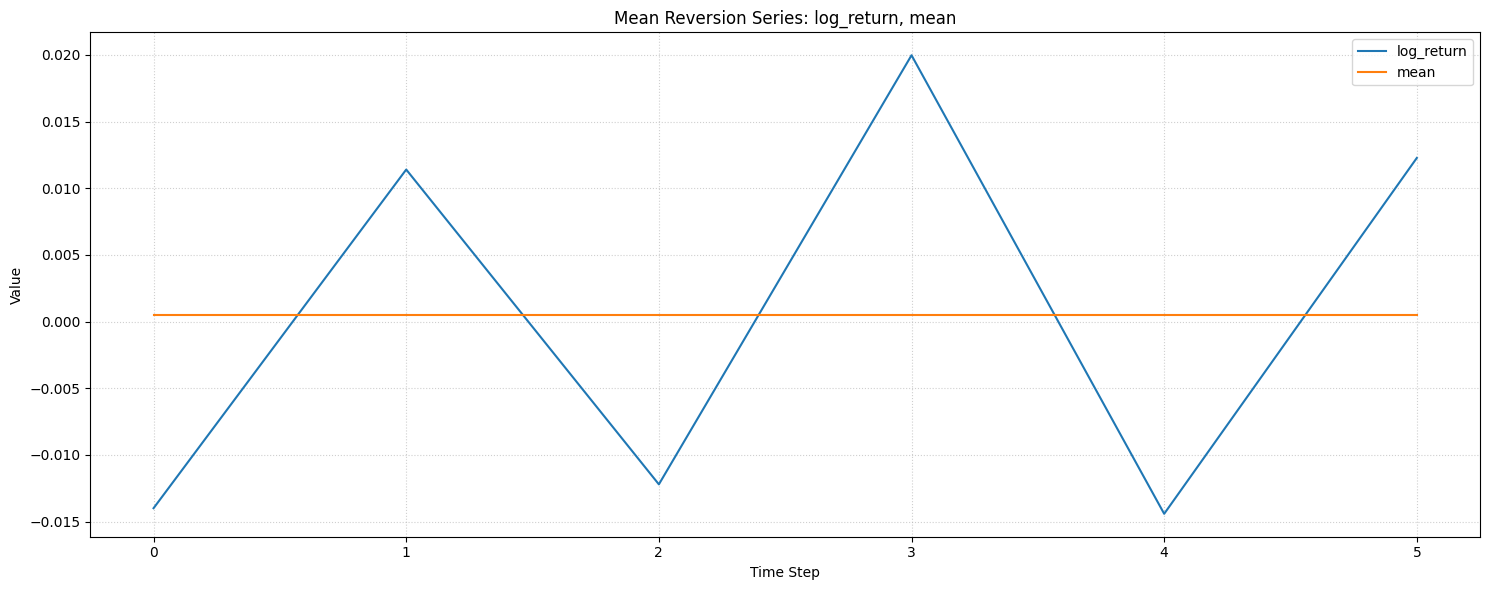

In [11]:
research.plot_multiple_lines(mean_reversion_df, ['log_return', 'mean'], 'Mean Reversion')

## Strategy development

### load time series

In [12]:
sym = 'BTCUSDT'
time_interval='1d'

ts = pl.read_csv(f"../historical_data/{sym}_{time_interval}_ohlc_updated.csv", try_parse_dates=True).sort('datetime')
ts

datetime,open,high,low,close
datetime[μs],f64,f64,f64,f64
2025-05-05 00:00:00,94230.2,95165.1,93445.1,94696.7
2025-05-06 00:00:00,94696.7,96879.5,93327.0,96798.9
2025-05-07 00:00:00,96798.9,97700.0,95718.5,96988.4
2025-05-08 00:00:00,96988.4,104305.3,96831.5,103228.1
2025-05-09 00:00:00,103228.0,104373.0,102240.0,102941.9
…,…,…,…,…
2026-05-01 00:00:00,76305.4,78879.9,76265.4,78192.0
2026-05-02 00:00:00,78191.9,79145.0,77979.3,78652.9
2026-05-03 00:00:00,78652.8,79428.9,78027.0,78529.0


#### add target and features


In [13]:
forecast_horizon = 1
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=3)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64
2025-05-05 00:00:00,94230.2,95165.1,93445.1,94696.7,null,null,null,null
2025-05-06 00:00:00,94696.7,96879.5,93327.0,96798.9,0.021956,null,null,null
2025-05-07 00:00:00,96798.9,97700.0,95718.5,96988.4,0.001956,0.021956,null,null
2025-05-08 00:00:00,96988.4,104305.3,96831.5,103228.1,0.06235,0.001956,0.021956,null
2025-05-09 00:00:00,103228.0,104373.0,102240.0,102941.9,-0.002776,0.06235,0.001956,0.021956
…,…,…,…,…,…,…,…,…
2026-05-01 00:00:00,76305.4,78879.9,76265.4,78192.0,0.024424,0.007307,-0.007211,-0.013449
2026-05-02 00:00:00,78191.9,79145.0,77979.3,78652.9,0.005877,0.024424,0.007307,-0.007211
2026-05-03 00:00:00,78652.8,79428.9,78027.0,78529.0,-0.001577,0.005877,0.024424,0.007307


In [14]:
test_size = 0.25
_, trades = research.timeseries_split(ts, test_size)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64
2026-02-03 00:00:00,78692.5,79163.0,72889.2,75732.4,-0.038342,0.022632,-0.022814,-0.067601
2026-02-04 00:00:00,75732.4,76952.5,71838.0,73137.4,-0.034866,-0.038342,0.022632,-0.022814
2026-02-05 00:00:00,73137.5,73316.3,62233.3,62868.1,-0.151301,-0.034866,-0.038342,0.022632
2026-02-06 00:00:00,62868.1,71714.4,59800.0,70544.5,0.115205,-0.151301,-0.034866,-0.038342
2026-02-07 00:00:00,70544.5,71690.0,67250.0,69254.2,-0.01846,0.115205,-0.151301,-0.034866
…,…,…,…,…,…,…,…,…
2026-05-01 00:00:00,76305.4,78879.9,76265.4,78192.0,0.024424,0.007307,-0.007211,-0.013449
2026-05-02 00:00:00,78191.9,79145.0,77979.3,78652.9,0.005877,0.024424,0.007307,-0.007211
2026-05-03 00:00:00,78652.8,79428.9,78027.0,78529.0,-0.001577,0.005877,0.024424,0.007307


#### strategy decision #1, entry/exit signal

In [15]:
# 1. time based. exit 8 hours later
# 2. predicate based. prediction, but until certain condition is satisfied, make prediction



##### add model predictions

In [16]:
target = 'close_log_return'
features = [f'{target}_lag_3']
trades = research.add_model_predictions(trades, model, features)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32
2026-02-03 00:00:00,78692.5,79163.0,72889.2,75732.4,-0.038342,0.022632,-0.022814,-0.067601,0.001677
2026-02-04 00:00:00,75732.4,76952.5,71838.0,73137.4,-0.034866,-0.038342,0.022632,-0.022814,0.000494
2026-02-05 00:00:00,73137.5,73316.3,62233.3,62868.1,-0.151301,-0.034866,-0.038342,0.022632,-0.000707
2026-02-06 00:00:00,62868.1,71714.4,59800.0,70544.5,0.115205,-0.151301,-0.034866,-0.038342,0.000904
2026-02-07 00:00:00,70544.5,71690.0,67250.0,69254.2,-0.01846,0.115205,-0.151301,-0.034866,0.000812
…,…,…,…,…,…,…,…,…,…
2026-05-01 00:00:00,76305.4,78879.9,76265.4,78192.0,0.024424,0.007307,-0.007211,-0.013449,0.000246
2026-05-02 00:00:00,78191.9,79145.0,77979.3,78652.9,0.005877,0.024424,0.007307,-0.007211,0.000081
2026-05-03 00:00:00,78652.8,79428.9,78027.0,78529.0,-0.001577,0.005877,0.024424,0.007307,-0.000302


##### add directional signal

In [17]:
trades = trades.with_columns(pl.col('y_hat').sign().alias('dir_signal'))
trades


datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32
2026-02-03 00:00:00,78692.5,79163.0,72889.2,75732.4,-0.038342,0.022632,-0.022814,-0.067601,0.001677,1.0
2026-02-04 00:00:00,75732.4,76952.5,71838.0,73137.4,-0.034866,-0.038342,0.022632,-0.022814,0.000494,1.0
2026-02-05 00:00:00,73137.5,73316.3,62233.3,62868.1,-0.151301,-0.034866,-0.038342,0.022632,-0.000707,-1.0
2026-02-06 00:00:00,62868.1,71714.4,59800.0,70544.5,0.115205,-0.151301,-0.034866,-0.038342,0.000904,1.0
2026-02-07 00:00:00,70544.5,71690.0,67250.0,69254.2,-0.01846,0.115205,-0.151301,-0.034866,0.000812,1.0
…,…,…,…,…,…,…,…,…,…,…
2026-05-01 00:00:00,76305.4,78879.9,76265.4,78192.0,0.024424,0.007307,-0.007211,-0.013449,0.000246,1.0
2026-05-02 00:00:00,78191.9,79145.0,77979.3,78652.9,0.005877,0.024424,0.007307,-0.007211,0.000081,1.0
2026-05-03 00:00:00,78652.8,79428.9,78027.0,78529.0,-0.001577,0.005877,0.024424,0.007307,-0.000302,-1.0


#### calc trade log return

In [18]:
trades= trades.with_columns(
    (pl.col('close_log_return') * pl.col('dir_signal')).alias('trade_log_return')
)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64
2026-02-03 00:00:00,78692.5,79163.0,72889.2,75732.4,-0.038342,0.022632,-0.022814,-0.067601,0.001677,1.0,-0.038342
2026-02-04 00:00:00,75732.4,76952.5,71838.0,73137.4,-0.034866,-0.038342,0.022632,-0.022814,0.000494,1.0,-0.034866
2026-02-05 00:00:00,73137.5,73316.3,62233.3,62868.1,-0.151301,-0.034866,-0.038342,0.022632,-0.000707,-1.0,0.151301
2026-02-06 00:00:00,62868.1,71714.4,59800.0,70544.5,0.115205,-0.151301,-0.034866,-0.038342,0.000904,1.0,0.115205
2026-02-07 00:00:00,70544.5,71690.0,67250.0,69254.2,-0.01846,0.115205,-0.151301,-0.034866,0.000812,1.0,-0.01846
…,…,…,…,…,…,…,…,…,…,…,…
2026-05-01 00:00:00,76305.4,78879.9,76265.4,78192.0,0.024424,0.007307,-0.007211,-0.013449,0.000246,1.0,0.024424
2026-05-02 00:00:00,78191.9,79145.0,77979.3,78652.9,0.005877,0.024424,0.007307,-0.007211,0.000081,1.0,0.005877
2026-05-03 00:00:00,78652.8,79428.9,78027.0,78529.0,-0.001577,0.005877,0.024424,0.007307,-0.000302,-1.0,0.001577


#### calc cumulative trade log return

In [19]:
trades = trades.with_columns(
    pl.col('trade_log_return').cum_sum().alias('cum_trade_log_return')
)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64
2026-02-03 00:00:00,78692.5,79163.0,72889.2,75732.4,-0.038342,0.022632,-0.022814,-0.067601,0.001677,1.0,-0.038342,-0.038342
2026-02-04 00:00:00,75732.4,76952.5,71838.0,73137.4,-0.034866,-0.038342,0.022632,-0.022814,0.000494,1.0,-0.034866,-0.073208
2026-02-05 00:00:00,73137.5,73316.3,62233.3,62868.1,-0.151301,-0.034866,-0.038342,0.022632,-0.000707,-1.0,0.151301,0.078093
2026-02-06 00:00:00,62868.1,71714.4,59800.0,70544.5,0.115205,-0.151301,-0.034866,-0.038342,0.000904,1.0,0.115205,0.193298
2026-02-07 00:00:00,70544.5,71690.0,67250.0,69254.2,-0.01846,0.115205,-0.151301,-0.034866,0.000812,1.0,-0.01846,0.174838
…,…,…,…,…,…,…,…,…,…,…,…,…
2026-05-01 00:00:00,76305.4,78879.9,76265.4,78192.0,0.024424,0.007307,-0.007211,-0.013449,0.000246,1.0,0.024424,0.40919
2026-05-02 00:00:00,78191.9,79145.0,77979.3,78652.9,0.005877,0.024424,0.007307,-0.007211,0.000081,1.0,0.005877,0.415067
2026-05-03 00:00:00,78652.8,79428.9,78027.0,78529.0,-0.001577,0.005877,0.024424,0.007307,-0.000302,-1.0,0.001577,0.416644


#### display equity curve (log space)

In [20]:
research.plot_column(trades, 'cum_trade_log_return')

alt.Chart(...)

## Strategy decision #2: Trade sizing

In [21]:
#1. constant trade size
#2. compounding trade size

##### constant sizing

In [22]:
capital = 100
ratio = 1.0
trade_value = ratio * capital

# entry trade value and exit trade value
trades = trades.with_columns(
    pl.lit(trade_value).alias('entry_trade_value'),
    (trade_value * pl.col('trade_log_return').exp()).alias('exit_trade_value'),
    (trade_value / pl.col('open')).alias('trade_qty'),
).with_columns(
    (pl.col('trade_qty') * pl.col('dir_signal')).alias('signed_trade_qty')
)
trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty
datetime[μs],f64,f64,f64,f32,f64,f64,f64
2026-02-03 00:00:00,78692.5,75732.4,-0.038342,0.001677,100.0,96.238396,0.001271
2026-02-04 00:00:00,75732.4,73137.4,-0.034866,0.000494,100.0,96.573461,0.00132
2026-02-05 00:00:00,73137.5,62868.1,0.151301,-0.000707,100.0,116.334675,-0.001367
2026-02-06 00:00:00,62868.1,70544.5,0.115205,0.000904,100.0,112.210326,0.001591
2026-02-07 00:00:00,70544.5,69254.2,-0.01846,0.000812,100.0,98.170942,0.001418
…,…,…,…,…,…,…,…
2026-05-01 00:00:00,76305.4,78192.0,0.024424,0.000246,100.0,102.472433,0.001311
2026-05-02 00:00:00,78191.9,78652.9,0.005877,0.000081,100.0,100.589446,0.001279
2026-05-03 00:00:00,78652.8,78529.0,0.001577,-0.000302,100.0,100.157776,-0.001271


#### add trade gross profit and loss

In [23]:
trades = trades.with_columns(
    (pl.col('exit_trade_value') - pl.col('entry_trade_value')).alias('trade_gross_pnl')
)

trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64
2026-02-03 00:00:00,78692.5,75732.4,-0.038342,0.001677,100.0,96.238396,0.001271,-3.761604
2026-02-04 00:00:00,75732.4,73137.4,-0.034866,0.000494,100.0,96.573461,0.00132,-3.426539
2026-02-05 00:00:00,73137.5,62868.1,0.151301,-0.000707,100.0,116.334675,-0.001367,16.334675
2026-02-06 00:00:00,62868.1,70544.5,0.115205,0.000904,100.0,112.210326,0.001591,12.210326
2026-02-07 00:00:00,70544.5,69254.2,-0.01846,0.000812,100.0,98.170942,0.001418,-1.829058
…,…,…,…,…,…,…,…,…
2026-05-01 00:00:00,76305.4,78192.0,0.024424,0.000246,100.0,102.472433,0.001311,2.472433
2026-05-02 00:00:00,78191.9,78652.9,0.005877,0.000081,100.0,100.589446,0.001279,0.589446
2026-05-03 00:00:00,78652.8,78529.0,0.001577,-0.000302,100.0,100.157776,-0.001271,0.157776


#### Add transaction fees 

In [24]:
taker_fee = binance.TAKER_FEE
maker_fee = binance.MAKER_FEE

trades = trades.with_columns(
    ((pl.col('entry_trade_value') * taker_fee + pl.col('exit_trade_value') * taker_fee) * pl.col('dir_signal').abs()).alias('taker_fee'),
    ((pl.col('entry_trade_value') * maker_fee + pl.col('exit_trade_value') * maker_fee) * pl.col('dir_signal').abs()).alias('maker_fee')
)

trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl', 'maker_fee', 'taker_fee')


datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl,maker_fee,taker_fee
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64,f64,f64
2026-02-03 00:00:00,78692.5,75732.4,-0.038342,0.001677,100.0,96.238396,0.001271,-3.761604,0.088307,0.088307
2026-02-04 00:00:00,75732.4,73137.4,-0.034866,0.000494,100.0,96.573461,0.00132,-3.426539,0.088458,0.088458
2026-02-05 00:00:00,73137.5,62868.1,0.151301,-0.000707,100.0,116.334675,-0.001367,16.334675,0.097351,0.097351
2026-02-06 00:00:00,62868.1,70544.5,0.115205,0.000904,100.0,112.210326,0.001591,12.210326,0.095495,0.095495
2026-02-07 00:00:00,70544.5,69254.2,-0.01846,0.000812,100.0,98.170942,0.001418,-1.829058,0.089177,0.089177
…,…,…,…,…,…,…,…,…,…,…
2026-05-01 00:00:00,76305.4,78192.0,0.024424,0.000246,100.0,102.472433,0.001311,2.472433,0.091113,0.091113
2026-05-02 00:00:00,78191.9,78652.9,0.005877,0.000081,100.0,100.589446,0.001279,0.589446,0.090265,0.090265
2026-05-03 00:00:00,78652.8,78529.0,0.001577,-0.000302,100.0,100.157776,-0.001271,0.157776,0.090071,0.090071


##### calc net trade pnl

In [25]:
trades = trades.with_columns(
    (pl.col('trade_gross_pnl') - pl.col('maker_fee')).alias('trade_net_maker_pnl'),
    (pl.col('trade_gross_pnl') - pl.col('taker_fee')).alias('trade_net_taker_pnl'),
)


trades.select('datetime', 'open', 'close', 'trade_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl', 'trade_net_taker_pnl', 'trade_net_maker_pnl')

datetime,open,close,trade_log_return,y_hat,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl,trade_net_taker_pnl,trade_net_maker_pnl
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64,f64,f64
2026-02-03 00:00:00,78692.5,75732.4,-0.038342,0.001677,100.0,96.238396,0.001271,-3.761604,-3.849911,-3.849911
2026-02-04 00:00:00,75732.4,73137.4,-0.034866,0.000494,100.0,96.573461,0.00132,-3.426539,-3.514997,-3.514997
2026-02-05 00:00:00,73137.5,62868.1,0.151301,-0.000707,100.0,116.334675,-0.001367,16.334675,16.237325,16.237325
2026-02-06 00:00:00,62868.1,70544.5,0.115205,0.000904,100.0,112.210326,0.001591,12.210326,12.114831,12.114831
2026-02-07 00:00:00,70544.5,69254.2,-0.01846,0.000812,100.0,98.170942,0.001418,-1.829058,-1.918235,-1.918235
…,…,…,…,…,…,…,…,…,…,…
2026-05-01 00:00:00,76305.4,78192.0,0.024424,0.000246,100.0,102.472433,0.001311,2.472433,2.381321,2.381321
2026-05-02 00:00:00,78191.9,78652.9,0.005877,0.000081,100.0,100.589446,0.001279,0.589446,0.499181,0.499181
2026-05-03 00:00:00,78652.8,78529.0,0.001577,-0.000302,100.0,100.157776,-0.001271,0.157776,0.067705,0.067705


#### display equity curves for constant sizing

In [26]:
def equity_curve(capital, col_name, suffix):
    return (capital + (pl.col(col_name).cum_sum())).alias(f'equity_curve_{suffix}')

trades = trades.with_columns(
    equity_curve(capital, 'trade_net_taker_pnl', 'taker'),
    equity_curve(capital, 'trade_net_maker_pnl', 'maker'),
    equity_curve(capital, 'trade_gross_pnl', 'gross'),
)

trades.select('datetime', 'equity_curve_gross', 'equity_curve_taker', 'equity_curve_maker')

datetime,equity_curve_gross,equity_curve_taker,equity_curve_maker
datetime[μs],f64,f64,f64
2026-02-03 00:00:00,96.238396,96.150089,96.150089
2026-02-04 00:00:00,92.811858,92.635092,92.635092
2026-02-05 00:00:00,109.146533,108.872417,108.872417
2026-02-06 00:00:00,121.356859,120.987248,120.987248
2026-02-07 00:00:00,119.527801,119.069013,119.069013
…,…,…,…
2026-05-01 00:00:00,145.095686,137.155393,137.155393
2026-05-02 00:00:00,145.685133,137.654575,137.654575
2026-05-03 00:00:00,145.842909,137.72228,137.72228


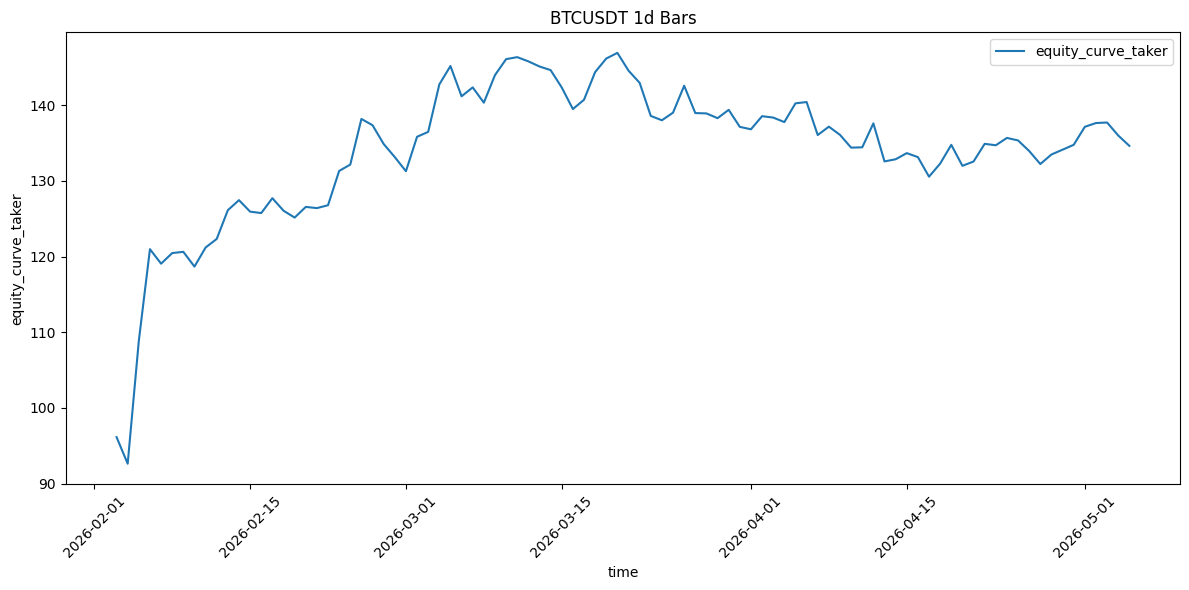

In [27]:
research.plot_static_timeseries(trades, sym, 'equity_curve_taker',time_interval)

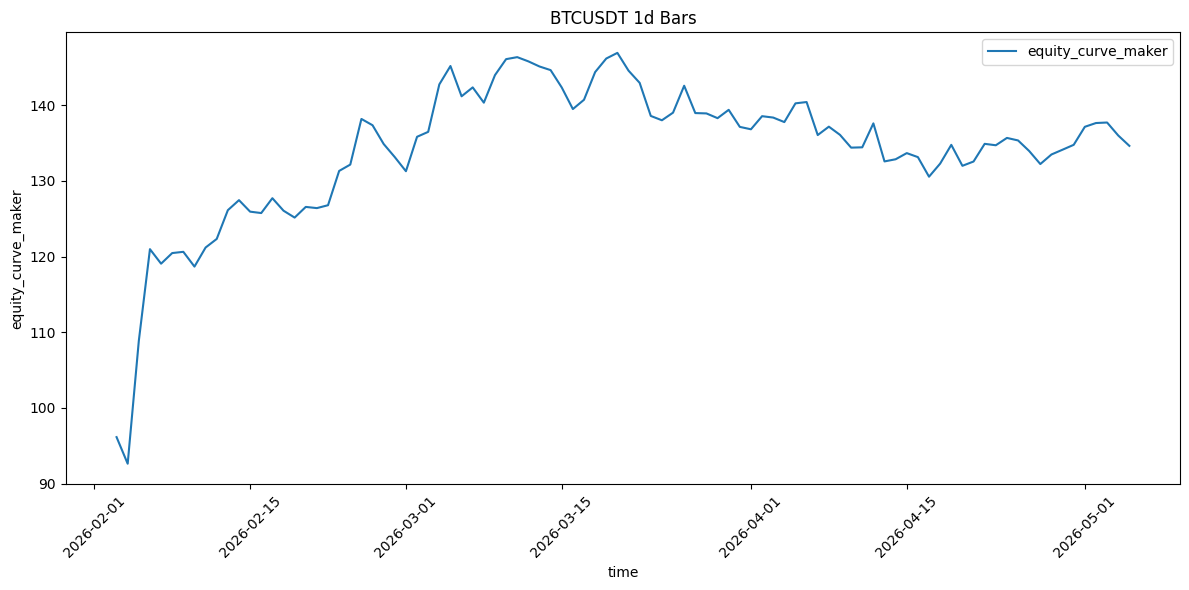

In [28]:
research.plot_static_timeseries(trades, sym, 'equity_curve_maker',time_interval)

### calculate total net return using constant sizing

In [29]:
constant_sizing_net_return = trades['equity_curve_taker'][-1] / capital - 1
constant_sizing_net_return

0.34637730816296264

#### compounding trade sizing

reinvesting earnings basically.

- if you put in 100, and earn two, your next trade you would put in 102
- principle of time additivity

In [30]:
trades = trades.with_columns(
    ((pl.col('cum_trade_log_return').exp()) * capital).shift().fill_null(capital).alias('entry_trade_value'),
    ((pl.col('cum_trade_log_return').exp()) * capital).alias('exit_trade_value')
).with_columns(
    (pl.col('entry_trade_value') / pl.col('open') * pl.col('dir_signal')).alias('signed_trade_qty'),
    (pl.col('exit_trade_value') - pl.col('entry_trade_value')).alias('trade_gross_pnl'),
)

trades.select('datetime', 'open', 'close', 'trade_log_return', 'entry_trade_value', 'exit_trade_value', 'signed_trade_qty', 'trade_gross_pnl')

datetime,open,close,trade_log_return,entry_trade_value,exit_trade_value,signed_trade_qty,trade_gross_pnl
datetime[μs],f64,f64,f64,f64,f64,f64,f64
2026-02-03 00:00:00,78692.5,75732.4,-0.038342,100.0,96.238396,0.001271,-3.761604
2026-02-04 00:00:00,75732.4,73137.4,-0.034866,96.238396,92.94075,0.001271,-3.297646
2026-02-05 00:00:00,73137.5,62868.1,0.151301,92.94075,108.12232,-0.001271,15.18157
2026-02-06 00:00:00,62868.1,70544.5,0.115205,108.12232,121.324408,0.00172,13.202088
2026-02-07 00:00:00,70544.5,69254.2,-0.01846,121.324408,119.105314,0.00172,-2.219094
…,…,…,…,…,…,…,…
2026-05-01 00:00:00,76305.4,78192.0,0.024424,146.927085,150.559759,0.001926,3.632674
2026-05-02 00:00:00,78191.9,78652.9,0.005877,150.559759,151.447229,0.001926,0.887469
2026-05-03 00:00:00,78652.8,78529.0,0.001577,151.447229,151.686176,-0.001926,0.238948


##### add transaction fees

In [31]:
trades = research.add_tx_fees(trades, binance.MAKER_FEE, binance.TAKER_FEE)
trades.select('datetime', 'entry_trade_value', 'exit_trade_value', 'tx_fee_maker', 'tx_fee_taker')

datetime,entry_trade_value,exit_trade_value,tx_fee_maker,tx_fee_taker
datetime[μs],f64,f64,f64,f64
2026-02-03 00:00:00,100.0,96.238396,0.088307,0.088307
2026-02-04 00:00:00,96.238396,92.94075,0.085131,0.085131
2026-02-05 00:00:00,92.94075,108.12232,0.090478,0.090478
2026-02-06 00:00:00,108.12232,121.324408,0.103251,0.103251
2026-02-07 00:00:00,121.324408,119.105314,0.108193,0.108193
…,…,…,…,…
2026-05-01 00:00:00,146.927085,150.559759,0.133869,0.133869
2026-05-02 00:00:00,150.559759,151.447229,0.135903,0.135903
2026-05-03 00:00:00,151.447229,151.686176,0.13641,0.13641


#### add trade net pnl

In [32]:
trades = trades.with_columns(
    (pl.col('trade_gross_pnl') - pl.col('tx_fee_taker')).alias('trade_net_taker_pnl')
)

trades.select('datetime', 'open', 'close', 'close_log_return', 'y_hat', 'entry_trade_value', 'exit_trade_value', 'trade_gross_pnl', 'trade_net_taker_pnl')

datetime,open,close,close_log_return,y_hat,entry_trade_value,exit_trade_value,trade_gross_pnl,trade_net_taker_pnl
datetime[μs],f64,f64,f64,f32,f64,f64,f64,f64
2026-02-03 00:00:00,78692.5,75732.4,-0.038342,0.001677,100.0,96.238396,-3.761604,-3.849911
2026-02-04 00:00:00,75732.4,73137.4,-0.034866,0.000494,96.238396,92.94075,-3.297646,-3.382777
2026-02-05 00:00:00,73137.5,62868.1,-0.151301,-0.000707,92.94075,108.12232,15.18157,15.091091
2026-02-06 00:00:00,62868.1,70544.5,0.115205,0.000904,108.12232,121.324408,13.202088,13.098837
2026-02-07 00:00:00,70544.5,69254.2,-0.01846,0.000812,121.324408,119.105314,-2.219094,-2.327287
…,…,…,…,…,…,…,…,…
2026-05-01 00:00:00,76305.4,78192.0,0.024424,0.000246,146.927085,150.559759,3.632674,3.498805
2026-05-02 00:00:00,78191.9,78652.9,0.005877,0.000081,150.559759,151.447229,0.887469,0.751566
2026-05-03 00:00:00,78652.8,78529.0,-0.001577,-0.000302,151.447229,151.686176,0.238948,0.102538


### Display equity curve (compounding)

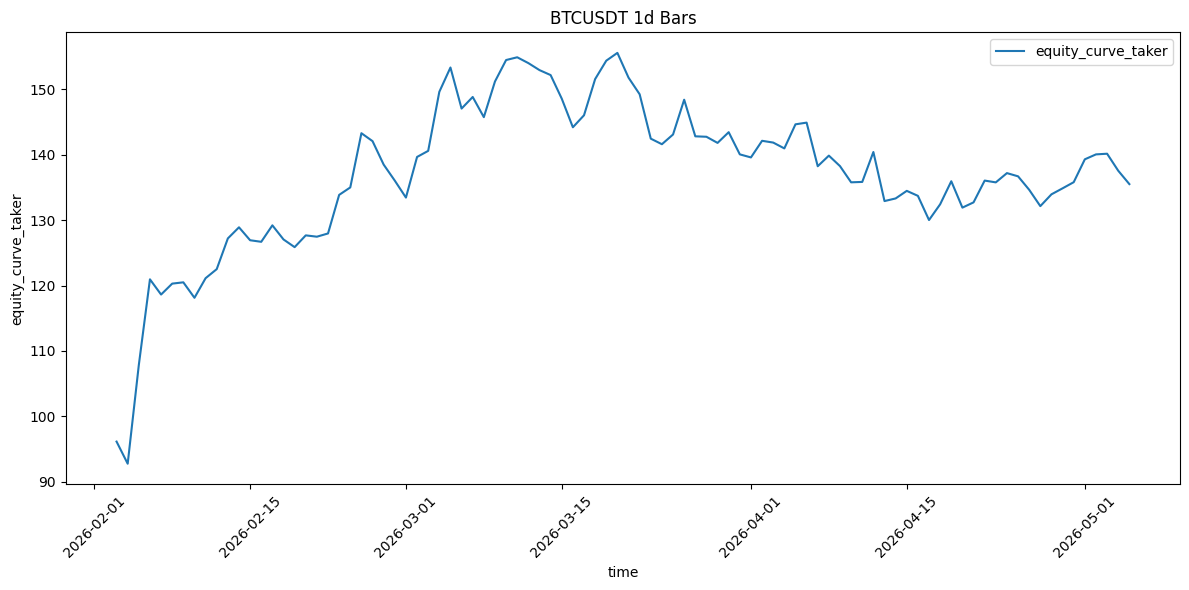

In [33]:
trades = research.add_equity_curve(trades, capital, 'trade_net_taker_pnl', 'taker')
research.plot_static_timeseries(trades, sym, 'equity_curve_taker', time_interval)

### calculate total net return for compounding trade sizing

In [34]:
compound_total_net_return = trades['equity_curve_taker'][-1] / capital - 1
compound_total_net_return

0.35514930285688506

In [35]:
constant_sizing_net_return

0.34637730816296264

In [36]:
np.round(compound_total_net_return - constant_sizing_net_return, 3)

np.float64(0.009)

### Strategy decision #3, leverage

borrowing money?


In [37]:
leverage = 4
trades = research.add_compounding_trades(trades, capital, leverage, maker_fee, taker_fee)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return,entry_trade_value,exit_trade_value,trade_qty,signed_trade_qty,trade_gross_pnl,taker_fee,maker_fee,trade_net_maker_pnl,trade_net_taker_pnl,equity_curve_taker,equity_curve_maker,equity_curve_gross,tx_fee_maker,tx_fee_taker
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-02-03 00:00:00,78692.5,79163.0,72889.2,75732.4,-0.038342,0.022632,-0.022814,-0.067601,0.001677,1.0,-0.038342,-0.038342,400.0,384.953585,0.001271,0.005083,-15.046415,0.088307,0.088307,-15.399644,-15.399644,84.600356,84.600356,84.953585,0.353229,0.353229
2026-02-04 00:00:00,75732.4,76952.5,71838.0,73137.4,-0.034866,-0.038342,0.022632,-0.022814,0.000494,1.0,-0.034866,-0.073208,384.953585,371.763002,0.00132,0.005083,-13.190584,0.088458,0.088458,-13.531106,-13.531106,71.06925,71.06925,71.763002,0.340522,0.340522
2026-02-05 00:00:00,73137.5,73316.3,62233.3,62868.1,-0.151301,-0.034866,-0.038342,0.022632,-0.000707,-1.0,0.151301,0.078093,371.763002,432.489281,0.001367,-0.005083,60.726279,0.097351,0.097351,60.364366,60.364366,131.433616,131.433616,132.489281,0.361914,0.361914
2026-02-06 00:00:00,62868.1,71714.4,59800.0,70544.5,0.115205,-0.151301,-0.034866,-0.038342,0.000904,1.0,0.115205,0.193298,432.489281,485.297632,0.001591,0.006879,52.808351,0.095495,0.095495,52.395347,52.395347,183.828963,183.828963,185.297632,0.413004,0.413004
2026-02-07 00:00:00,70544.5,71690.0,67250.0,69254.2,-0.01846,0.115205,-0.151301,-0.034866,0.000812,1.0,-0.01846,0.174838,485.297632,476.421256,0.001418,0.006879,-8.876376,0.089177,0.089177,-9.30915,-9.30915,174.519813,174.519813,176.421256,0.432773,0.432773
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-05-01 00:00:00,76305.4,78879.9,76265.4,78192.0,0.024424,0.007307,-0.007211,-0.013449,0.000246,1.0,0.024424,0.40919,587.708342,602.239038,0.001311,0.007702,14.530696,0.091113,0.091113,13.99522,13.99522,257.223538,257.223538,302.239038,0.535476,0.535476
2026-05-02 00:00:00,78191.9,79145.0,77979.3,78652.9,0.005877,0.024424,0.007307,-0.007211,0.000081,1.0,0.005877,0.415067,602.239038,605.788915,0.001279,0.007702,3.549877,0.090265,0.090265,3.006264,3.006264,260.229802,260.229802,305.788915,0.543613,0.543613
2026-05-03 00:00:00,78652.8,79428.9,78027.0,78529.0,-0.001577,0.005877,0.024424,0.007307,-0.000302,-1.0,0.001577,0.416644,605.788915,606.744705,0.001271,-0.007702,0.95579,0.090071,0.090071,0.41015,0.41015,260.639953,260.639953,306.744705,0.54564,0.54564


#### calculate total net return

In [38]:
trades['equity_curve_taker'][-1] / capital -1

1.4205972114275403

#### increase to 8x leverage? (US legal limit)

In [39]:
leverage = 8
trades = research.add_compounding_trades(trades, capital, leverage, maker_fee, taker_fee)
trades

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return,entry_trade_value,exit_trade_value,trade_qty,signed_trade_qty,trade_gross_pnl,taker_fee,maker_fee,trade_net_maker_pnl,trade_net_taker_pnl,equity_curve_taker,equity_curve_maker,equity_curve_gross,tx_fee_maker,tx_fee_taker
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-02-03 00:00:00,78692.5,79163.0,72889.2,75732.4,-0.038342,0.022632,-0.022814,-0.067601,0.001677,1.0,-0.038342,-0.038342,800.0,769.90717,0.001271,0.010166,-30.09283,0.088307,0.088307,-30.799288,-30.799288,69.200712,69.200712,69.90717,0.706458,0.706458
2026-02-04 00:00:00,75732.4,76952.5,71838.0,73137.4,-0.034866,-0.038342,0.022632,-0.022814,0.000494,1.0,-0.034866,-0.073208,769.90717,743.526003,0.00132,0.010166,-26.381167,0.088458,0.088458,-27.062212,-27.062212,42.1385,42.1385,43.526003,0.681045,0.681045
2026-02-05 00:00:00,73137.5,73316.3,62233.3,62868.1,-0.151301,-0.034866,-0.038342,0.022632,-0.000707,-1.0,0.151301,0.078093,743.526003,864.978561,0.001367,-0.010166,121.452558,0.097351,0.097351,120.728731,120.728731,162.867231,162.867231,164.978561,0.723827,0.723827
2026-02-06 00:00:00,62868.1,71714.4,59800.0,70544.5,0.115205,-0.151301,-0.034866,-0.038342,0.000904,1.0,0.115205,0.193298,864.978561,970.595264,0.001591,0.013759,105.616703,0.095495,0.095495,104.790695,104.790695,267.657926,267.657926,270.595264,0.826008,0.826008
2026-02-07 00:00:00,70544.5,71690.0,67250.0,69254.2,-0.01846,0.115205,-0.151301,-0.034866,0.000812,1.0,-0.01846,0.174838,970.595264,952.842511,0.001418,0.013759,-17.752753,0.089177,0.089177,-18.6183,-18.6183,249.039626,249.039626,252.842511,0.865547,0.865547
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-05-01 00:00:00,76305.4,78879.9,76265.4,78192.0,0.024424,0.007307,-0.007211,-0.013449,0.000246,1.0,0.024424,0.40919,1175.416684,1204.478075,0.001311,0.015404,29.061392,0.091113,0.091113,27.990439,27.990439,414.447076,414.447076,504.478075,1.070953,1.070953
2026-05-02 00:00:00,78191.9,79145.0,77979.3,78652.9,0.005877,0.024424,0.007307,-0.007211,0.000081,1.0,0.005877,0.415067,1204.478075,1211.577829,0.001279,0.015404,7.099754,0.090265,0.090265,6.012529,6.012529,420.459605,420.459605,511.577829,1.087225,1.087225
2026-05-03 00:00:00,78652.8,79428.9,78027.0,78529.0,-0.001577,0.005877,0.024424,0.007307,-0.000302,-1.0,0.001577,0.416644,1211.577829,1213.489409,0.001271,-0.015404,1.91158,0.090071,0.090071,0.8203,0.8203,421.279905,421.279905,513.489409,1.09128,1.09128


In [40]:
trades['equity_curve_taker'][-1] / capital -1

2.8411944228550805

##### wr hasnt changed

In [41]:
trades.select((pl.col('trade_log_return') > 0).mean())

trade_log_return
f64
0.532609


##### basic liquidation model

closing a position

In [42]:
maintenance_margin = 0.005

def long_liquidation_price(p, l, mmr):
    return (p * l) / (l + 1 - mmr * l)

def short_liquidation_price(p, l, mmr):
    return (p * l) / (l - 1 + mmr * 1)

##### show how leverage affects long positions

In [43]:
long_liquidation_price(200, 2, maintenance_margin)

133.7792642140468

In [44]:
long_liquidation_price(200, 4, maintenance_margin)

160.64257028112448

In [45]:
long_liquidation_price(200, 10, maintenance_margin)

182.64840182648402

#### show how leverage affects short positions

In [46]:
short_liquidation_price(200, 2, maintenance_margin)

398.00995024875624

In [47]:
short_liquidation_price(200, 4, maintenance_margin)

266.22296173044924

### add liquidation prices

In [48]:
leverage = 4

In [49]:
trades = trades.with_columns(
    pl.when(pl.col('dir_signal') == 1)
    .then(
        (pl.col('open') * leverage) / (leverage + 1 - maintenance_margin * leverage)
    )
    .when(pl.col('dir_signal') == -1)
    .then(
        (pl.col('open') * leverage) / (leverage - 1 + maintenance_margin * leverage )
    )
    .otherwise(None)
    .alias('liquidation_price')
)

trades.select('datetime', 'open', 'high', 'low', 'close', 'liquidation_price', 'dir_signal')

datetime,open,high,low,close,liquidation_price,dir_signal
datetime[μs],f64,f64,f64,f64,f64,f32
2026-02-03 00:00:00,78692.5,79163.0,72889.2,75732.4,63206.827309,1.0
2026-02-04 00:00:00,75732.4,76952.5,71838.0,73137.4,60829.236948,1.0
2026-02-05 00:00:00,73137.5,73316.3,62233.3,62868.1,96870.860927,-1.0
2026-02-06 00:00:00,62868.1,71714.4,59800.0,70544.5,50496.465863,1.0
2026-02-07 00:00:00,70544.5,71690.0,67250.0,69254.2,56662.248996,1.0
…,…,…,…,…,…,…
2026-05-01 00:00:00,76305.4,78879.9,76265.4,78192.0,61289.477912,1.0
2026-05-02 00:00:00,78191.9,79145.0,77979.3,78652.9,62804.738956,1.0
2026-05-03 00:00:00,78652.8,79428.9,78027.0,78529.0,104175.89404,-1.0


### add liquidation flag

In [50]:
trades = trades.with_columns([
    # worst price based on direction
    pl.when(pl.col('dir_signal') == 1)
        .then(pl.col('low'))
        .otherwise(pl.col('high'))
        .alias('worst_price'),
    # liquidation flag
    pl.when(
        (pl.col('dir_signal') == 1) & (pl.col('low') <= pl.col('liquidation_price'))
    )
    .then(True)
    .when(
        (pl.col('dir_signal') == -1) & (pl.col('high') >= pl.col('liquidation_price'))
    )
    .then(True)
    .otherwise(False)
    .alias('liquidated')
])

trades.select('datetime', 'open', 'high', 'low', 'close', 'liquidation_price', 'dir_signal', 'worst_price', 'liquidated')


datetime,open,high,low,close,liquidation_price,dir_signal,worst_price,liquidated
datetime[μs],f64,f64,f64,f64,f64,f32,f64,bool
2026-02-03 00:00:00,78692.5,79163.0,72889.2,75732.4,63206.827309,1.0,72889.2,false
2026-02-04 00:00:00,75732.4,76952.5,71838.0,73137.4,60829.236948,1.0,71838.0,false
2026-02-05 00:00:00,73137.5,73316.3,62233.3,62868.1,96870.860927,-1.0,73316.3,false
2026-02-06 00:00:00,62868.1,71714.4,59800.0,70544.5,50496.465863,1.0,59800.0,false
2026-02-07 00:00:00,70544.5,71690.0,67250.0,69254.2,56662.248996,1.0,67250.0,false
…,…,…,…,…,…,…,…,…
2026-05-01 00:00:00,76305.4,78879.9,76265.4,78192.0,61289.477912,1.0,76265.4,false
2026-05-02 00:00:00,78191.9,79145.0,77979.3,78652.9,62804.738956,1.0,77979.3,false
2026-05-03 00:00:00,78652.8,79428.9,78027.0,78529.0,104175.89404,-1.0,79428.9,false


### find liquidated trades

In [51]:
trades.filter(pl.col('liquidated') == True)

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,y_hat,dir_signal,trade_log_return,cum_trade_log_return,entry_trade_value,exit_trade_value,trade_qty,signed_trade_qty,trade_gross_pnl,taker_fee,maker_fee,trade_net_maker_pnl,trade_net_taker_pnl,equity_curve_taker,equity_curve_maker,equity_curve_gross,tx_fee_maker,tx_fee_taker,liquidation_price,worst_price,liquidated
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
